In [1]:
!pip install gdown

In [2]:
import gdown

url = 'https://drive.google.com/uc?id=1JKnvWEFRjvd-6HNpcQZRg5OJ1QEulc35'
output = 'ds_xray.zip'
gdown.download(url, output, quiet=False)

import zipfile
import os

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall('ds_xray')

print("Dataset descargado y descomprimido en la carpeta 'ds_xray/'")
path = os.path.join(os.getcwd(), "ds_xray")

Downloading...
From (original): https://drive.google.com/uc?id=1JKnvWEFRjvd-6HNpcQZRg5OJ1QEulc35
From (redirected): https://drive.google.com/uc?id=1JKnvWEFRjvd-6HNpcQZRg5OJ1QEulc35&confirm=t&uuid=c874c15a-cedc-4e0e-b76a-8927356a32c6
To: C:\Users\Chelo\OneDrive\Documents\Cursos\Especializacion en IA\4to Bimestre\Vision por computadora II\vpcII_carreras_fajardo_mas\ds_xray.zip
100%|██████████| 140M/140M [00:14<00:00, 9.33MB/s] 


Dataset descargado y descomprimido en la carpeta 'ds_xray/'


In [3]:
import os
from glob import glob
from PIL import Image
import pandas as pd

# Ruta base
base_dir = "ds_xray"
image_paths = glob(os.path.join(base_dir, '**', 'images', '*.jpg'), recursive=True)
label_paths = [p.replace('images', 'labels').replace('.jpg', '.txt') for p in image_paths]

# Construir un DataFrame base
data = []
for img, lbl in zip(image_paths, label_paths):
    if os.path.exists(lbl):
        with open(lbl) as f:
            lines = f.readlines()
            for line in lines:
                class_id = int(line.split()[0])
                data.append({
                    'image_path': img,
                    'label_path': lbl,
                    'class_id': class_id
                })

df = pd.DataFrame(data)

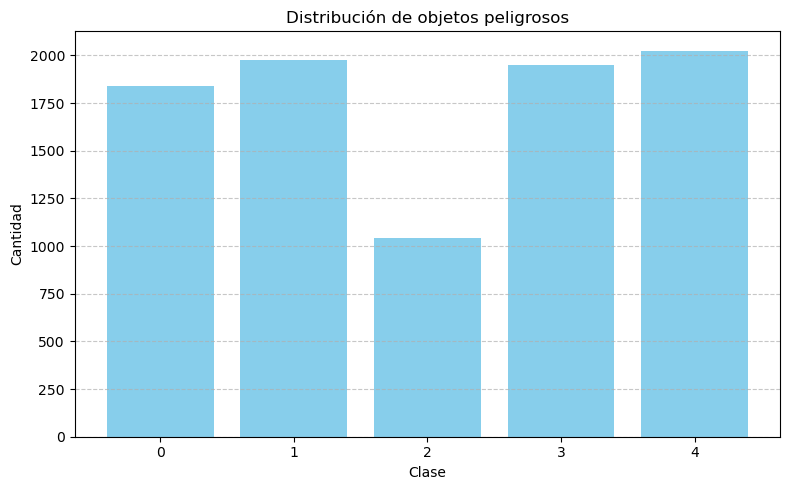

In [4]:
import matplotlib.pyplot as plt

# Definir nombres de las clases según el orden en los archivos
class_names = ['0', '1', '2', '3', '4']

# Contar ocurrencias y mapear nombres
class_counts = df['class_id'].value_counts().sort_index()
class_labels = [class_names[i] for i in class_counts.index]

# Graficar
plt.figure(figsize=(8, 5))
plt.bar(class_labels, class_counts.values, color='skyblue')
plt.title("Distribución de objetos peligrosos")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

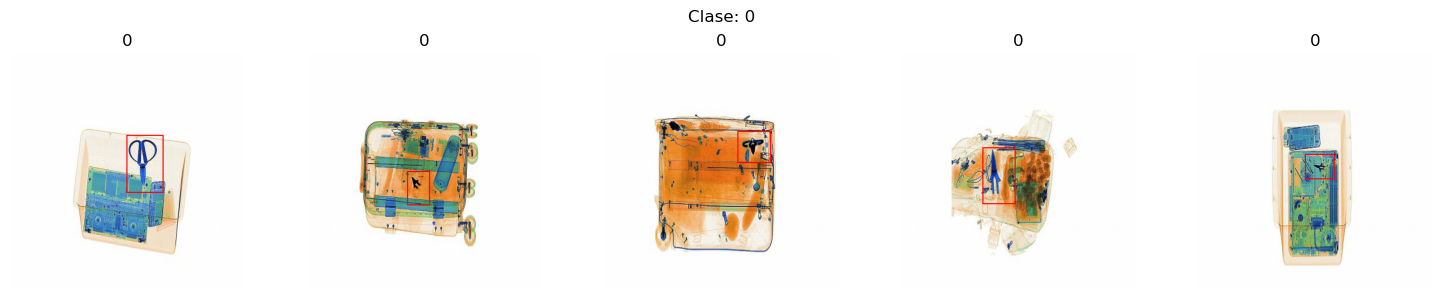

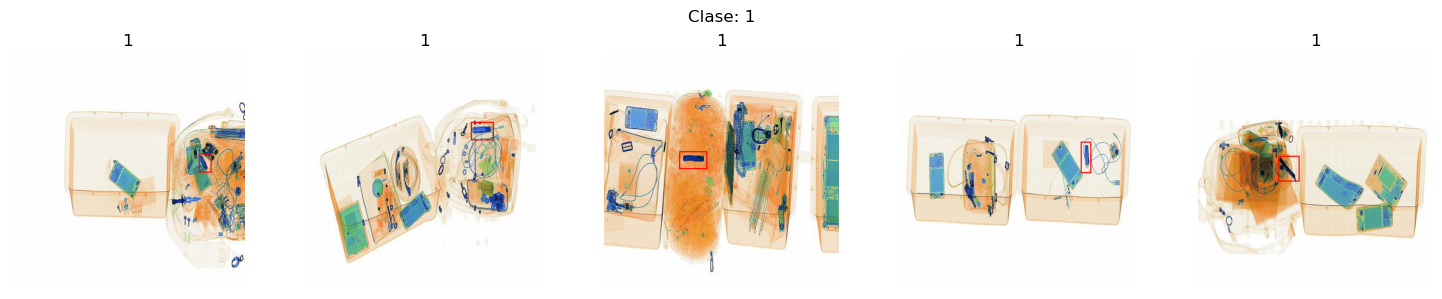

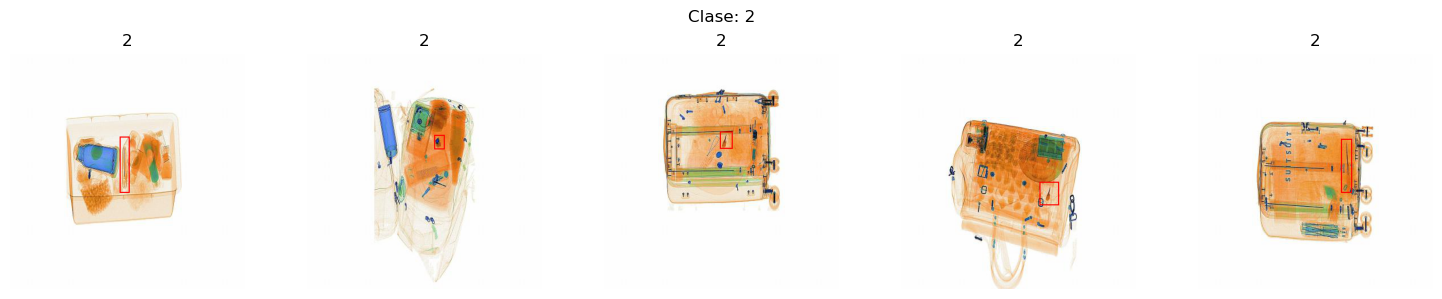

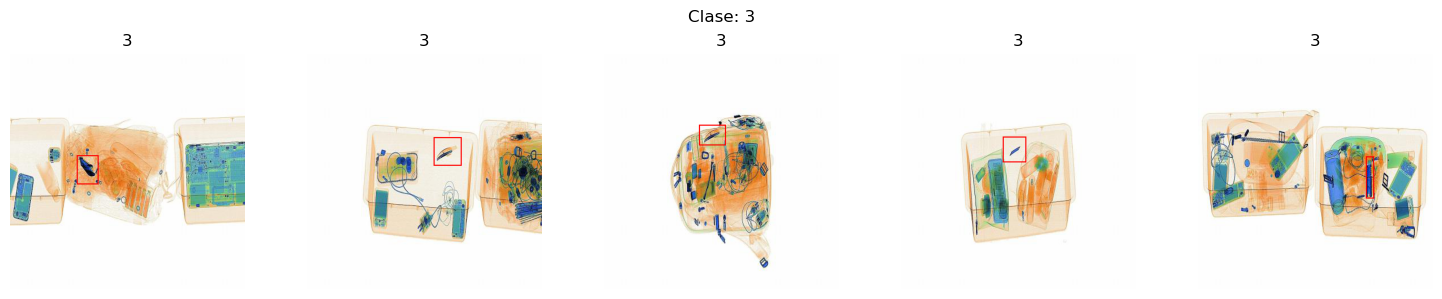

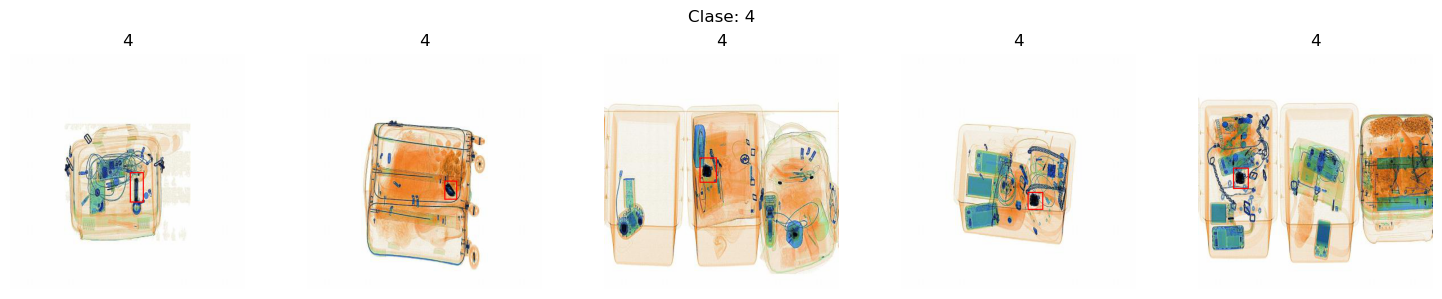

In [5]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

for class_id in range(5):
    subset = df[df['class_id'] == class_id].head(5)

    plt.figure(figsize=(15, 3))
    for i, row in enumerate(subset.itertuples()):
        img = Image.open(row.image_path).convert('RGB')
        draw = ImageDraw.Draw(img)
        with open(row.label_path) as f:
            for line in f:
                parts = list(map(float, line.strip().split()))
                cls, xc, yc, w, h = parts
                x1 = (xc - w/2) * img.width
                y1 = (yc - h/2) * img.height
                x2 = (xc + w/2) * img.width
                y2 = (yc + h/2) * img.height
                draw.rectangle([x1, y1, x2, y2], outline='red', width=2)

        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(class_names[class_id])
        plt.axis('off')

    plt.suptitle(f'Clase: {class_names[class_id]}')
    plt.tight_layout()
    plt.show()


Distribución de clases:
       Cantidad
Clase          
0          1841
1          1975
2          1041
3          1948
4          2025

Color promedio por clase (RGB):
                   r           g           b
class_id                                    
0         237.592968  233.016242  223.502628
1         237.717710  233.230958  223.745791
2         238.598878  233.933163  224.755158
3         238.447045  233.885902  224.666032
4         237.324372  232.780429  223.180893


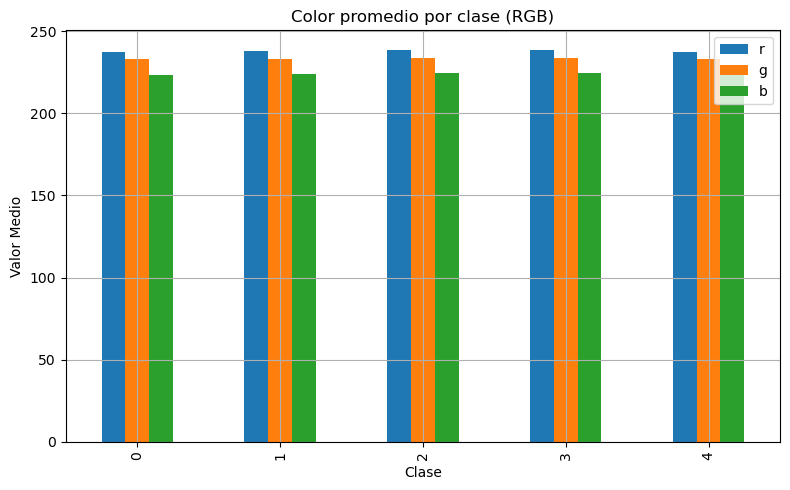

In [6]:
import os
from glob import glob
from collections import Counter
import pandas as pd
from PIL import Image, ImageStat
import matplotlib.pyplot as plt

# Ruta base
base_dir = "ds_xray"

# Paso 1: Cargar imágenes y etiquetas
image_paths = glob(os.path.join(base_dir, '**', 'images', '*.jpg'), recursive=True)
data = []
for img_path in image_paths:
    label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')
    if os.path.exists(label_path):
        with open(label_path) as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    data.append({
                        'image_path': img_path,
                        'label_path': label_path,
                        'class_id': class_id
                    })

df = pd.DataFrame(data)

# Paso 2: Filtrar imágenes con múltiples clases
label_counts = df.groupby('image_path')['class_id'].nunique().reset_index()
multi_class_images = label_counts[label_counts['class_id'] > 1]['image_path']
df_single = df[~df['image_path'].isin(multi_class_images)]

# Una fila por imagen
df_single_unique = df_single.groupby('image_path').first().reset_index()

# Paso 3: Distribución de clases
class_distribution = Counter(df_single_unique['class_id'])
df_distribution = pd.DataFrame.from_dict(dict(sorted(class_distribution.items())), orient='index', columns=["Cantidad"])
df_distribution.index.name = 'Clase'
print("Distribución de clases:")
print(df_distribution)

# Paso 4: Calcular color promedio (RGB)
def get_avg_rgb(image_path):
    try:
        image = Image.open(image_path).convert('RGB')
        stat = ImageStat.Stat(image)
        return stat.mean  # [R, G, B]
    except:
        return [0, 0, 0]

df_single_unique['avg_rgb'] = df_single_unique['image_path'].apply(get_avg_rgb)
df_single_unique[['r', 'g', 'b']] = pd.DataFrame(df_single_unique['avg_rgb'].tolist(), index=df_single_unique.index)

# Paso 5: Promedio de color por clase
df_color = df_single_unique.groupby('class_id')[['r', 'g', 'b']].mean()
print("\nColor promedio por clase (RGB):")
print(df_color)

# Paso 6: Visualización del promedio de color
df_color.plot(kind='bar', figsize=(8, 5), title='Color promedio por clase (RGB)')
plt.xlabel('Clase')
plt.ylabel('Valor Medio')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
🔹 1. Extraer embeddings usando ResNet50 + canal azul

In [11]:
import torchvision.models as models
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model = nn.Sequential(*list(model.children())[:-1])  # sin capa de clasificación
model.to(device)
model.eval()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Chelo/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:12<00:00, 8.33MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


🔹 2. Función para obtener embeddings desde el canal azul

In [40]:
def get_embedding_blue(img_path):
    try:
        image = Image.open(img_path).convert('RGB').getchannel('B')
        image = transforms.Resize((224, 224))(image)
        tensor = transforms.ToTensor()(image)
        tensor_3ch = torch.stack([tensor, tensor, tensor]).unsqueeze(0).to(device)

        with torch.no_grad():
            embedding = model(tensor_3ch).squeeze().cpu().numpy()

        return embedding
    except:
        return None

🔹 3. Recolectar embeddings desde carpeta train

In [43]:
!pip install tqdm

In [49]:
from glob import glob
import pandas as pd
from tqdm import tqdm

image_paths = sorted(glob('ds_xray/train/images/*.jpg'))
embeddings_data = []

for img_path in tqdm(image_paths[:]):  # podés ajustar el límite si querés todo
    label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')
    if os.path.exists(label_path):
        with open(label_path) as f:
            lines = f.readlines()
            class_id = int(lines[0].split()[0])
            emb = get_embedding_blue(img_path)
            if emb is not None:
                embeddings_data.append((img_path, class_id, emb))

df_emb = pd.DataFrame(embeddings_data, columns=['image_path', 'class_id', 'embedding'])


100%|██████████| 6181/6181 [00:13<00:00, 465.33it/s]


In [51]:
validos = 0
for img_path in tqdm(image_paths[:]):
    label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')
    if os.path.exists(label_path):
        with open(label_path) as f:
            lines = f.readlines()
            class_id = int(lines[0].split()[0])
            emb = get_embedding_blue(img_path)
            if emb is not None:
                embeddings_data.append((img_path, class_id, emb))
                validos += 1

print("Total de embeddings válidos:", validos)

100%|██████████| 6181/6181 [00:13<00:00, 468.22it/s]

Total de embeddings válidos: 0


🔹 4. Aplicar t-SNE

In [28]:
from sklearn.manifold import TSNE
import numpy as np

X = np.stack(df_emb['embedding'].values)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

df_emb['tsne_x'] = X_tsne[:, 0]
df_emb['tsne_y'] = X_tsne[:, 1]

ValueError: need at least one array to stack